In [1]:
print('aa')

aa


In [2]:
import matplotlib.pyplot as plt
from scapy.all import rdpcap
from datetime import datetime, timedelta
import numpy as np

# Function to classify packet types
def classify_packet(packet):
    if packet.haslayer("ARP"):
        return "ARP"
    elif packet.haslayer("ICMP"):
        return "ICMP"
    elif packet.haslayer("TCP"):
        return "TCP"
    elif packet.haslayer("UDP"):
        return "UDP"
    else:
        return "Other"

# Function to process packets and count types
def process_pcap(file_path):
    packets = rdpcap(file_path)
    packet_counts = {}

    for packet in packets:
        packet_type = classify_packet(packet)
        if packet_type in packet_counts:
            packet_counts[packet_type] += 1
        else:
            packet_counts[packet_type] = 1

    return packet_counts

# Function to process packets and extract timestamps by type
def process_pcap_by_time(file_path):
    packets = rdpcap(file_path)
    packet_times = {}

    for packet in packets:
        packet_type = classify_packet(packet)
        packet_time = datetime.fromtimestamp(float(packet.time))

        if packet_type not in packet_times:
            packet_times[packet_type] = []

        packet_times[packet_type].append(packet_time)

    return packet_times

# Plot packet type distribution
def plot_packet_types(packet_counts, title):
    plt.bar(packet_counts.keys(), packet_counts.values())
    plt.title(title)
    plt.xlabel("Packet Type")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Plot packet types over time with binning
def plot_packet_types_binned_by_time(packet_times, bin_size, title):
    plt.figure(figsize=(10, 6))

    for packet_type, times in packet_times.items():
        if packet_type in ["UDP", "Other"]:
            continue

        # Convert times to seconds and create bins
        min_time = min(times)
        max_time = max(times)
        bins = np.arange(min_time, max_time + timedelta(seconds=bin_size), timedelta(seconds=bin_size)).astype(datetime)

        # Count packets in each bin
        binned_counts, _ = np.histogram(times, bins=bins)
        bin_centers = [min_time + timedelta(seconds=i * bin_size) for i in range(len(binned_counts))]

        # Plot the counts over time
        plt.plot(bin_centers, binned_counts, label=packet_type)

    plt.title(title)
    plt.xlabel("Time")
    plt.ylabel("Packet Count")
    plt.legend()
    plt.gcf().autofmt_xdate()
    plt.tight_layout()
    plt.show()


In [12]:
import seaborn as sns

sns.set_theme(style="whitegrid")
def plot_all_three_subplots(packet_times1, packet_times2, packet_times3, bin_size=5,
                            titles=("Targeted PLC (PLC3)", "Malicious Attacker Component", "Scada")):
    """
    Plots three packet-time distributions (for PLC, Attacker, Scada)
    in a single figure with three vertically stacked subplots,
    sharing the same X (time) and Y (packet count) axes.

    :param packet_times1: dict of packet_type -> list of datetime timestamps
    :param packet_times2: dict of packet_type -> list of datetime timestamps
    :param packet_times3: dict of packet_type -> list of datetime timestamps
    :param bin_size: bin size in seconds
    :param titles: tuple/list of strings for subplot titles
    """

    # Gather all timestamps in one list to determine global min and max
    all_times = []
    for pt_dict in [packet_times1, packet_times2, packet_times3]:
        for times in pt_dict.values():
            all_times.extend(times)

    if not all_times:
        print("No packet timestamps found.")
        return

    global_min_time = min(all_times)
    global_max_time = max(all_times)

    # Create global bins (from min to max time)
    bins = np.arange(global_min_time,
                     global_max_time + timedelta(seconds=bin_size),
                     timedelta(seconds=bin_size)).astype(datetime)

    fig, axes = plt.subplots(nrows=3, ncols=1, sharex=True, figsize=(6, 6))

    # Helper function to plot a single dataset on a given axis
    def plot_binned_times(ax, packet_times, title):
        for packet_type, times in packet_times.items():
            # Histogram the times into the same global bins
            binned_counts, _ = np.histogram(times, bins=bins)
            # We'll use the left edges, plus half bin_size for midpoint
            bin_centers = [bin + timedelta(seconds=bin_size / 2) for bin in bins[:-1]]

            # ARP packets get a marker; others do not
            if packet_type == "ARP":
                ax.plot(bin_centers, binned_counts, label=packet_type, linestyle='-',linewidth=3)
            if packet_type == "TCP":
                ax.plot(bin_centers, binned_counts, label=packet_type, linestyle='-')

        ax.set_title(title)
        ax.set_ylabel("Packet Count")
        ax.legend(loc='upper right')

    # Plot each dataset in its respective subplot
    plot_binned_times(axes[0], packet_times1, titles[0])
    plot_binned_times(axes[1], packet_times2, titles[1])
    plot_binned_times(axes[2], packet_times3, titles[2])

    # Only the bottom plot needs an X label
    axes[2].set_xlabel("Time")
    #xticks should not appear
    axes[0].set_xticks([])


    # Auto-format the x-axis dates
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.savefig('output/ScadaCase2/CyberLayerPLC3.png')

    plt.show()

In [ ]:
file_path = '../examples/EdenTown/Scada_Case/2_DoS_NoGuard/output/PLC3-eth0.pcap'
file_path2 = '../examples/EdenTown/Scada_Case/2_DoS_NoGuard/output/plc3Attac-eth0.pcap'
file_path3 = '../examples/EdenTown/Scada_Case/2_DoS_NoGuard/output/scada-eth0.pcap'


packet_times1 = process_pcap_by_time(file_path)
packet_times2 = process_pcap_by_time(file_path2)
packet_times3 = process_pcap_by_time(file_path3)

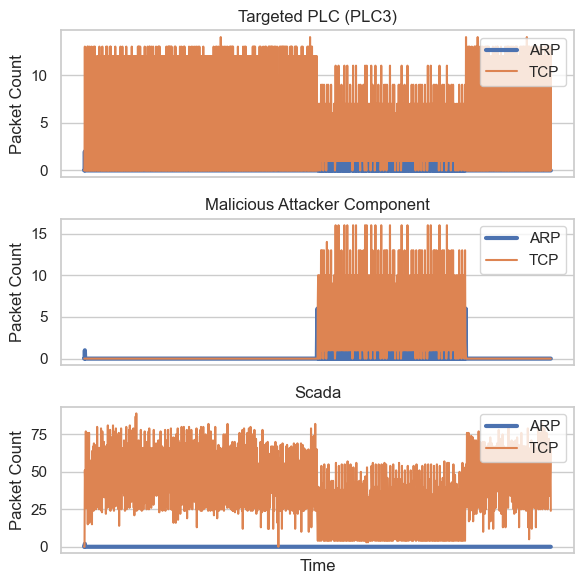

In [14]:


plot_all_three_subplots(packet_times1, packet_times2, packet_times3, bin_size=5)


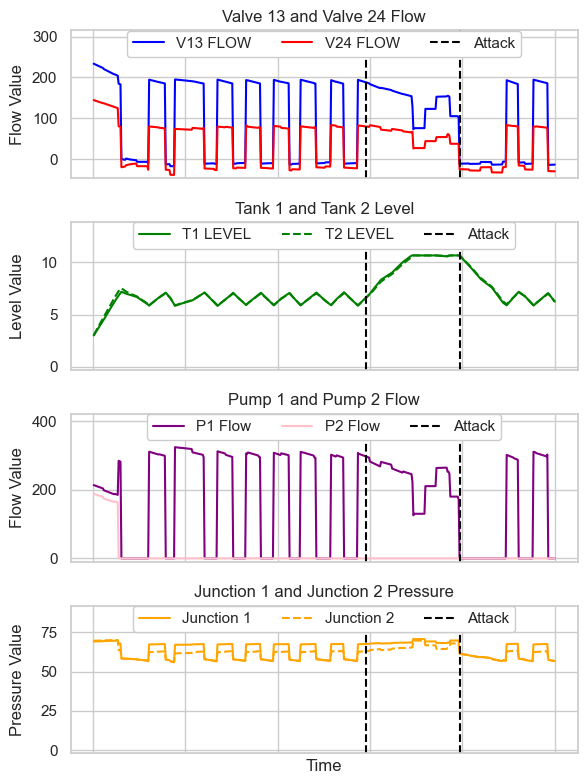

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def find_attack_intervals(data, flag_column):
    attack_intervals = []
    attack_start = None

    for index, flag in enumerate(data[flag_column]):
        if flag == 1 and attack_start is None:
            attack_start = data['iteration'].iloc[index]
        elif flag == 0 and attack_start is not None:
            attack_end = data['iteration'].iloc[index]
            attack_intervals.append((attack_start, attack_end))
            attack_start = None

    return attack_intervals

# Load CSV files
ground_truth_df = pd.read_csv('../examples/EdenTown/Scada_Case/2_DoS_NoGuard/output/ground_truth.csv')
scada_df = pd.read_csv('../examples/EdenTown/Scada_Case/2_DoS_NoGuard/output/scada_values.csv')

# Drop the first row
ground_truth_df = ground_truth_df.drop(0)

attack_intervals = find_attack_intervals(ground_truth_df, 'plc2AttackerUnit')
attack_start, attack_end = attack_intervals[0]

# Create a figure with three subplots (valves removed from network)
fig, axes = plt.subplots(3, 1, figsize=(6, 6), gridspec_kw={'height_ratios': [1, 1, 1]})

def adjust_ylim(ax, columns, df):
    """ Increase y-limit dynamically to create more space for the legend. """
    min_val = df[columns].min().min()
    min_val = min_val if min_val <= 0 else 0
    max_val = df[columns].max().max()
    padding = (max_val - min_val) * 0.3  # Add 30% padding above
    ax.set_ylim(min_val - padding * 0.1, max_val + padding)  # Extra space for legend

# First subplot: Tank Level
axes[0].plot(ground_truth_df['iteration'], ground_truth_df['T1_LEVEL'], label='T1 LEVEL', color='green')
axes[0].plot(ground_truth_df['iteration'], ground_truth_df['T2_LEVEL'], label='T2 LEVEL', color='green', linestyle='--')
axes[0].axvline(x=attack_start, color='black', linestyle='--', label='Attack')
axes[0].axvline(x=attack_end, color='black', linestyle='--', label='')
axes[0].set_title("Tank 1 and Tank 2 Level")
axes[0].set_ylabel("Level Value")
adjust_ylim(axes[0], ['T1_LEVEL', 'T2_LEVEL'], ground_truth_df)

# Second subplot: Pump Flow
axes[1].plot(ground_truth_df['iteration'], ground_truth_df['P1_FLOW'], label='P1 Flow', color='purple')
axes[1].plot(ground_truth_df['iteration'], ground_truth_df['P2_FLOW'], label='P2 Flow', color='pink')
axes[1].axvline(x=attack_start, color='black', linestyle='--', label='Attack')
axes[1].axvline(x=attack_end, color='black', linestyle='--', label='')
axes[1].set_ylabel("Flow Value")
axes[1].set_title("Pump 1 and Pump 2 Flow")
adjust_ylim(axes[1], ['P1_FLOW', 'P2_FLOW'], ground_truth_df)

# Third subplot: Pressure
axes[2].plot(ground_truth_df['iteration'], ground_truth_df['J1_LEVEL'], label='Junction 1', color='orange')
axes[2].plot(ground_truth_df['iteration'], ground_truth_df['J2_LEVEL'], label='Junction 2', color='orange', linestyle='--')
axes[2].axvline(x=attack_start, color='black', linestyle='--', label='Attack')
axes[2].axvline(x=attack_end, color='black', linestyle='--', label='')
axes[2].set_title("Junction 1 and Junction 2 Pressure")
axes[2].set_ylabel("Pressure Value")
adjust_ylim(axes[2], ['J1_LEVEL', 'J2_LEVEL'], ground_truth_df)

# Hide x-ticks for all subplots except last
for ax in axes:
    ax.tick_params(axis='x', which='both', bottom=False, labelbottom=False)
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=3, frameon=True,fancybox=True,framealpha=1)
    ax.yaxis.set_label_coords(-0.09, 0.5)



axes[2].set_xlabel("Time")

# Adjust layout for better spacing
plt.tight_layout()

# Save the plot
plt.savefig('output/ScadaCase2/PhysicalLayerGround.png')

# Display the plots
plt.show()


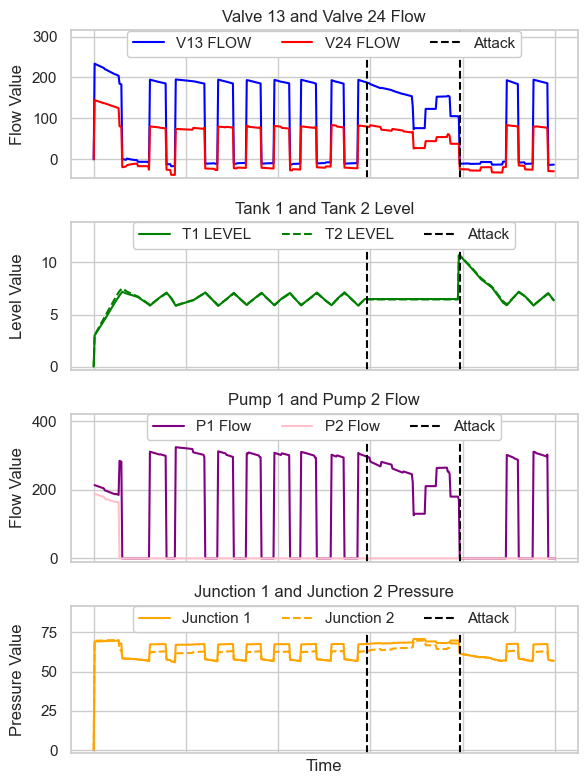

In [ ]:
##################################
# SCADA Layer visualization (3 subplots - valves removed)
##################################
fig2, axes2 = plt.subplots(3, 1, figsize=(6, 6), sharex=True)

# First subplot: Tank Level
axes2[0].plot(scada_df['iteration'], scada_df['T1'], label='T1 LEVEL', color='green')
axes2[0].plot(scada_df['iteration'], scada_df['T2'], label='T2 LEVEL', color='green', linestyle='--')
axes2[0].set_title("Tank 1 and Tank 2 Level")
axes2[0].set_ylabel("Level Value")
axes2[0].axvline(x=attack_start, color='black', linestyle='--', label='Attack')
axes2[0].axvline(x=attack_end, color='black', linestyle='--', label='')
adjust_ylim(axes2[0], ['T1', 'T2'], scada_df)

# Second subplot: Pump Flow
axes2[1].plot(ground_truth_df['iteration'], ground_truth_df['P1_FLOW'], label='P1 Flow', color='purple')
axes2[1].plot(ground_truth_df['iteration'], ground_truth_df['P2_FLOW'], label='P2 Flow', color='pink')
axes2[1].axvline(x=attack_start, color='black', linestyle='--', label='Attack')
axes2[1].axvline(x=attack_end, color='black', linestyle='--', label='')
axes2[1].set_ylabel("Flow Value")
axes2[1].set_title("Pump 1 and Pump 2 Flow")
adjust_ylim(axes2[1], ['P1_FLOW', 'P2_FLOW'], ground_truth_df)

# Third subplot: Junction Pressure
axes2[2].plot(scada_df['iteration'], scada_df['J1'], label='Junction 1', color='orange')
axes2[2].plot(scada_df['iteration'], scada_df['J2'], label='Junction 2', color='orange',linestyle='--')
axes2[2].axvline(x=attack_start, color='black', linestyle='--', label='Attack')
axes2[2].axvline(x=attack_end, color='black', linestyle='--', label='')
axes2[2].set_title("Junction 1 and Junction 2 Pressure")
axes2[2].set_ylabel("Pressure Value")
adjust_ylim(axes2[2], ['J1', 'J2'], scada_df)

# Hide x-ticks for all subplots
for ax in axes2:
    ax.tick_params(axis='x', which='both', bottom=False, labelbottom=False)
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=3, frameon=True,fancybox=True,framealpha=1)
    ax.yaxis.set_label_coords(-0.09, 0.5)

axes2[2].set_xlabel("Time")

# Adjust layout for better spacing
plt.tight_layout()
plt.savefig('output/ScadaCase2/ScadaLayer.png')
plt.show()

# Visuzalize with guarrail the groundtruth


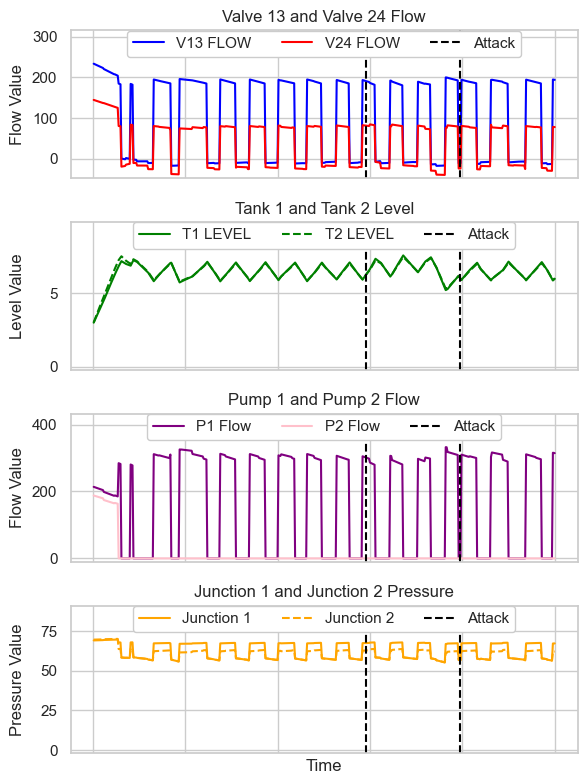

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def find_attack_intervals(data, flag_column):
    attack_intervals = []
    attack_start = None

    for index, flag in enumerate(data[flag_column]):
        if flag == 1 and attack_start is None:
            attack_start = data['iteration'].iloc[index]
        elif flag == 0 and attack_start is not None:
            attack_end = data['iteration'].iloc[index]
            attack_intervals.append((attack_start, attack_end))
            attack_start = None

    return attack_intervals

# Load CSV files (With Guard scenario)
ground_truth_df = pd.read_csv('../examples/EdenTown/Scada_Case/3_DoS_WithGuard/output/ground_truth.csv')
scada_df = pd.read_csv('../examples/EdenTown/Scada_Case/3_DoS_WithGuard/output/scada_values.csv')

# Drop the first row
ground_truth_df = ground_truth_df.drop(0)

attack_intervals = find_attack_intervals(ground_truth_df, 'plc2AttackerUnit')
attack_start, attack_end = attack_intervals[0]

# Create a figure with three subplots (valves removed from network)
fig, axes = plt.subplots(3, 1, figsize=(6, 6), gridspec_kw={'height_ratios': [1, 1, 1]})

def adjust_ylim(ax, columns, df):
    """ Increase y-limit dynamically to create more space for the legend. """
    min_val = df[columns].min().min()
    min_val = min_val if min_val <= 0 else 0
    max_val = df[columns].max().max()
    padding = (max_val - min_val) * 0.3  # Add 30% padding above
    ax.set_ylim(min_val - padding * 0.1, max_val + padding)  # Extra space for legend

# First subplot: Tank Level
axes[0].plot(ground_truth_df['iteration'], ground_truth_df['T1_LEVEL'], label='T1 LEVEL', color='green')
axes[0].plot(ground_truth_df['iteration'], ground_truth_df['T2_LEVEL'], label='T2 LEVEL', color='green', linestyle='--')
axes[0].axvline(x=attack_start, color='black', linestyle='--', label='Attack')
axes[0].axvline(x=attack_end, color='black', linestyle='--', label='')
axes[0].set_title("Tank 1 and Tank 2 Level")
axes[0].set_ylabel("Level Value")
adjust_ylim(axes[0], ['T1_LEVEL', 'T2_LEVEL'], ground_truth_df)

# Second subplot: Pump Flow
axes[1].plot(ground_truth_df['iteration'], ground_truth_df['P1_FLOW'], label='P1 Flow', color='purple')
axes[1].plot(ground_truth_df['iteration'], ground_truth_df['P2_FLOW'], label='P2 Flow', color='pink')
axes[1].axvline(x=attack_start, color='black', linestyle='--', label='Attack')
axes[1].axvline(x=attack_end, color='black', linestyle='--', label='')
axes[1].set_ylabel("Flow Value")
axes[1].set_title("Pump 1 and Pump 2 Flow")
adjust_ylim(axes[1], ['P1_FLOW', 'P2_FLOW'], ground_truth_df)

# Third subplot: Pressure
axes[2].plot(ground_truth_df['iteration'], ground_truth_df['J1_LEVEL'], label='Junction 1', color='orange')
axes[2].plot(ground_truth_df['iteration'], ground_truth_df['J2_LEVEL'], label='Junction 2', color='orange', linestyle='--')
axes[2].axvline(x=attack_start, color='black', linestyle='--', label='Attack')
axes[2].axvline(x=attack_end, color='black', linestyle='--', label='')
axes[2].set_title("Junction 1 and Junction 2 Pressure")
axes[2].set_ylabel("Pressure Value")
adjust_ylim(axes[2], ['J1_LEVEL', 'J2_LEVEL'], ground_truth_df)

# Hide x-ticks for all subplots except last
for ax in axes:
    ax.tick_params(axis='x', which='both', bottom=False, labelbottom=False)
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=3, frameon=True,fancybox=True,framealpha=1)
    ax.yaxis.set_label_coords(-0.09, 0.5)



axes[2].set_xlabel("Time")

# Adjust layout for better spacing
plt.tight_layout()

# Save the plot
plt.savefig('output/ScadaCase2/PhysicalLayerGroundGuard.png')

# Display the plots
plt.show()
